# Lab 04 — Unsupervised learning I: clustering and PCA

*Find structure without an answer key*

**Goal.** Choose the number of clusters from evidence rather than habit, compare K-means with DBSCAN, and use PCA as a compression step that is judged by how well a downstream model still works and by what the compressed images look like.

**Data.** `all_datasets/mall_customers_dataset.csv` and `all_datasets/optical_recognition_handwritten_digits.zip` (read in place)

**Reading.** Chapter 15 (How Unsupervised Learning Works), Chapter 16 (Clustering), Chapter 17 (Dimensionality Reduction and Representation)

**Run.** Open a terminal in the course folder, run `cd all_experiments` and `jupyter lab`, open this notebook, and choose **Restart Kernel and Run All Cells**.

**Evidence.** `results/lab04/` — K-means diagnostics, segment profiles, PCA budget, and figures; `models/digits_pca_logistic.joblib`

**How much is scaffolded?** Fully worked. There is no label in Parts A and B, so the evidence is internal: inertia, silhouette, and whether the groups make business sense.

**Workflow**

1. Part A — How many clusters? Elbow and silhouette
2. Part B — K-means versus DBSCAN
3. Part C — PCA as compression, judged by a downstream model
4. Try it yourself, with one solution

## Setup

Imports and paths. Notebooks run from `all_experiments/`, so the course folder is one level up; figures and tables go to `results/lab04/`.

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")  # avoids a known K-means warning on Windows
import zipfile
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent
DATA = PROJECT_ROOT / "all_datasets"
MODELS = PROJECT_ROOT / "models"
MODELS.mkdir(exist_ok=True)

RESULTS = PROJECT_ROOT / "results" / "lab04"
RESULTS.mkdir(parents=True, exist_ok=True)
print("course folder:", PROJECT_ROOT.name)

course folder: MACHINE LEARNING


## Part A — How many clusters? Elbow and silhouette

Two hundred mall customers, described by age, annual income, and a spending score. There is no label: the question is whether these customers fall into groups a marketing team could act on. The three columns are standardized first, otherwise income (tens of thousands) would decide every distance on its own.

In [2]:
customers = pd.read_csv(DATA / "mall_customers_dataset.csv")
print(customers.head())

features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
X = StandardScaler().fit_transform(customers[features])

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


K-means needs $k$ in advance, so run it for every $k$ from 2 to 8 and record two internal scores. *Inertia* is the total squared distance from each customer to its cluster centre: it always falls as $k$ grows. The *silhouette* compares how close each customer is to its own cluster against the nearest other cluster: higher means better separated, and it can go up or down.

k=2  inertia=389.4  silhouette=0.335
k=3  inertia=295.2  silhouette=0.358
k=4  inertia=205.2  silhouette=0.404
k=5  inertia=168.2  silhouette=0.417
k=6  inertia=133.9  silhouette=0.427
k=7  inertia=117.0  silhouette=0.417
k=8  inertia=103.8  silhouette=0.409


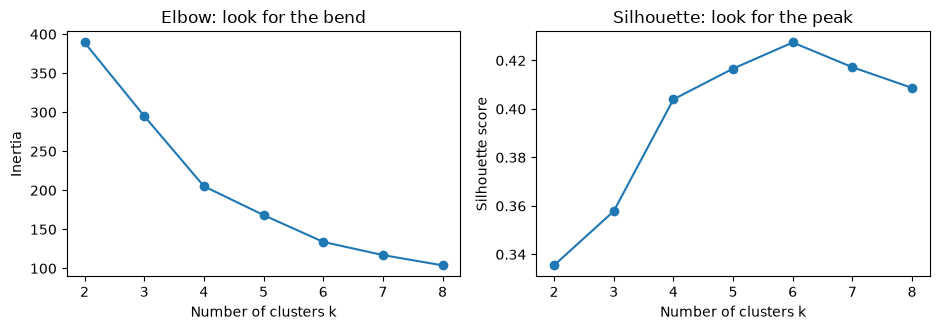

In [3]:
ks, inertias, silhouettes = [], [], []
for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = kmeans.fit_predict(X)
    ks.append(k)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X, labels))
    print(f"k={k}  inertia={kmeans.inertia_:.1f}  silhouette={silhouettes[-1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
axes[0].plot(ks, inertias, marker="o")
axes[0].set_xlabel("Number of clusters k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow: look for the bend")
axes[1].plot(ks, silhouettes, marker="o")
axes[1].set_xlabel("Number of clusters k")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette: look for the peak")
plt.tight_layout()
plt.savefig(RESULTS / "silhouette_look_for_the_peak.png", dpi=160, bbox_inches="tight")
plt.show()

**What to look for.** The elbow bends somewhere around 4 to 6, and the silhouette peaks at 6 with 5 close behind. Neither plot gives a single answer; together they say “five or six”, and the final choice should depend on which segments the team can actually use.

**What the output shows.** Inertia always falls as `k` grows, so the elbow is a judgement: it bends around 4–6. The silhouette peaks at `k=6` (0.427) with `k=5` close behind (0.417). Five or six groups are both defensible; the choice should depend on which segments a marketing team can act on.

## Part B — K-means versus DBSCAN

Two clustering philosophies. K-means assigns every customer to one of $k$ round groups around a centre. DBSCAN grows groups from dense regions and leaves customers in sparse areas unassigned, with the label $-1$ for noise; it needs no $k$, but it needs a radius `eps` and a minimum neighbour count.

In [4]:
kmeans = KMeans(n_clusters=5, n_init=30, random_state=42)
k_labels = kmeans.fit_predict(X)
print("K-means silhouette:", round(silhouette_score(X, k_labels), 3))

dbscan = DBSCAN(eps=0.75, min_samples=6)
d_labels = dbscan.fit_predict(X)
is_clustered = d_labels != -1
n_clusters = len(set(d_labels[is_clustered]))
print("DBSCAN clusters:", n_clusters, " noise points:", int((~is_clustered).sum()))
if n_clusters >= 2:
    print("DBSCAN silhouette (clustered points only):",
          round(silhouette_score(X[is_clustered], d_labels[is_clustered]), 3))

K-means silhouette: 0.417
DBSCAN clusters: 1  noise points: 14


A cluster is only useful if someone can describe it. Averaging the original columns per cluster turns the labels back into words.

In [5]:
segments = customers.copy()
segments["kmeans_cluster"] = k_labels
segments["dbscan_cluster"] = d_labels
profile = segments.groupby("kmeans_cluster")[features].mean().round(1)
profile["customers"] = segments["kmeans_cluster"].value_counts().sort_index()
print(profile)

                 Age  Annual Income (k$)  Spending Score (1-100)  customers
kmeans_cluster                                                             
0               46.2                26.8                    18.4         20
1               25.2                41.1                    62.2         54
2               32.9                86.1                    81.5         40
3               39.9                86.1                    19.4         39
4               55.6                54.4                    48.9         47


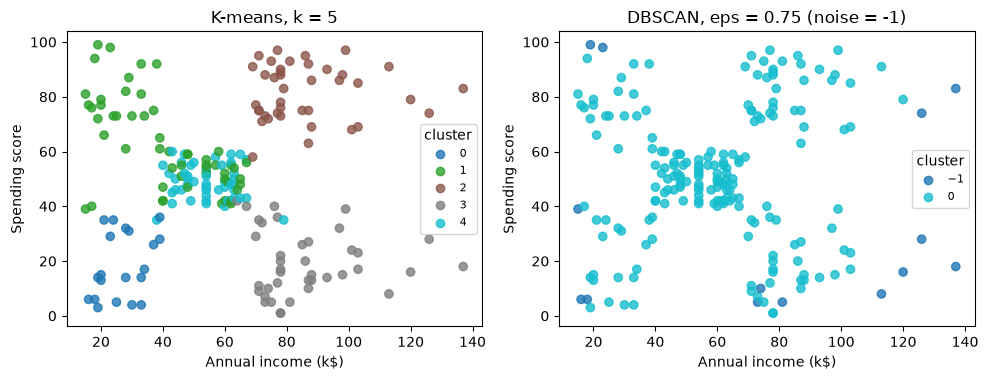

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.9))
panels = [(axes[0], k_labels, "K-means, k = 5"),
          (axes[1], d_labels, "DBSCAN, eps = 0.75 (noise = -1)")]
for ax, labels, title in panels:
    scatter = ax.scatter(customers["Annual Income (k$)"], customers["Spending Score (1-100)"],
                         c=labels, cmap="tab10", alpha=0.8)
    ax.set_xlabel("Annual income (k$)")
    ax.set_ylabel("Spending score")
    ax.set_title(title)
    ax.legend(*scatter.legend_elements(), title="cluster", fontsize=8, loc="center right")
plt.tight_layout()
plt.savefig(RESULTS / "figure_02.png", dpi=160, bbox_inches="tight")
plt.show()

**What to look for.** K-means finds the four corners of the income–spending plane plus a middle group, and each corner has an obvious name (affluent big spenders, affluent savers, and so on). DBSCAN with this radius sees one continuous cloud and a handful of stragglers. That is not a failure: it says there are no density gaps between the K-means groups, so they are a convenient partition of one population rather than five separate tribes. The Try-it task shrinks `eps` to see the other extreme.

**What the output shows.** With `k=5` the groups are easy to name: young moderate earners who spend freely, affluent high spenders, affluent low spenders, older low-income low spenders, and a middle group. DBSCAN with `eps=0.75` finds **one** cluster and 14 noise points: the customers form one continuous cloud with no density gaps. That is a result, not a failure. The Try-it task lowers `eps` to see the trade-off.

## Part C — PCA as compression, judged by a downstream model

Each handwritten digit is an $8\times8$ image, stored as 64 pixel brightnesses. The archive ships an official training file and an official test file; both are read straight from the zip. The test file stays closed until the end.

training digits: 3823  test digits: 1797


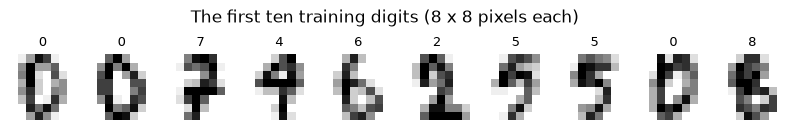

In [7]:
archive_path = DATA / "optical_recognition_handwritten_digits.zip"
columns = [f"pixel_{i}" for i in range(64)] + ["label"]
with zipfile.ZipFile(archive_path) as archive:
    members = {Path(name).name: name for name in archive.namelist()}
    train = pd.read_csv(archive.open(members["optdigits.tra"]), header=None, names=columns)
    test = pd.read_csv(archive.open(members["optdigits.tes"]), header=None, names=columns)

X_dev = train.drop(columns="label") / 16.0     # pixel values 0-16 -> 0-1
y_dev = train["label"]
X_test = test.drop(columns="label") / 16.0
y_test = test["label"]
print("training digits:", len(X_dev), " test digits:", len(X_test))

fig, axes = plt.subplots(1, 10, figsize=(10, 1.4))
for ax, (_, row), label in zip(axes, X_dev.head(10).iterrows(), y_dev.head(10)):
    ax.imshow(row.to_numpy().reshape(8, 8), cmap="gray_r")
    ax.set_title(str(label), fontsize=9)
    ax.axis("off")
plt.suptitle("The first ten training digits (8 x 8 pixels each)", y=1.05)
plt.savefig(RESULTS / "the_first_ten_training_digits_8_x_8_pixels_each.png", dpi=160, bbox_inches="tight")
plt.show()

PCA finds the directions in which the 64 pixel values vary most and keeps only the top few. The question is how many. Because a classifier will use the compressed images, the fair judge is that classifier's accuracy on a validation split carved from the training file. Three budgets are tried: keep 90%, 95%, or 99% of the variance.

In [8]:
X_fit, X_valid, y_fit, y_valid = train_test_split(
    X_dev, y_dev, test_size=0.25, random_state=42, stratify=y_dev
)

baseline = LogisticRegression(max_iter=2000).fit(X_fit, y_fit)
print("all 64 pixels: validation accuracy =",
      round(accuracy_score(y_valid, baseline.predict(X_valid)), 4))

for retained_variance in [0.90, 0.95, 0.99]:
    candidate = Pipeline([
        ("pca", PCA(n_components=retained_variance, svd_solver="full")),
        ("model", LogisticRegression(max_iter=2000)),
    ])
    candidate.fit(X_fit, y_fit)
    n_kept = candidate.named_steps["pca"].n_components_
    print(f"{retained_variance:.0%} variance: {n_kept:2d} components, "
          f"validation accuracy = {accuracy_score(y_valid, candidate.predict(X_valid)):.4f}")

all 64 pixels: validation accuracy = 0.955
90% variance: 21 components, validation accuracy = 0.9487
95% variance: 29 components, validation accuracy = 0.9540
99% variance: 41 components, validation accuracy = 0.9561


The 95% budget is locked, the pipeline is refitted on the whole training file, and the official test file is opened once. The full 64-pixel model is refitted the same way for a fair comparison.

In [9]:
final_model = Pipeline([
    ("pca", PCA(n_components=0.95, svd_solver="full")),
    ("model", LogisticRegression(max_iter=2000)),
])
final_model.fit(X_dev, y_dev)
full_model = LogisticRegression(max_iter=2000).fit(X_dev, y_dev)
pca = final_model.named_steps["pca"]

print("\nFINAL TEST (official test file)")
print("all 64 pixels accuracy:", round(accuracy_score(y_test, full_model.predict(X_test)), 4))
print("PCA components kept:", pca.n_components_,
      " variance retained:", round(pca.explained_variance_ratio_.sum(), 4))
print("PCA -> logistic accuracy:", round(accuracy_score(y_test, final_model.predict(X_test)), 4))


FINAL TEST (official test file)
all 64 pixels accuracy: 0.9477
PCA components kept: 29  variance retained: 0.9537
PCA -> logistic accuracy: 0.9477


What does “keep 95% of the variance” look like? Compress a few test digits to their component scores and rebuild the images from those scores alone. The cumulative-variance curve shows why so few components are enough.

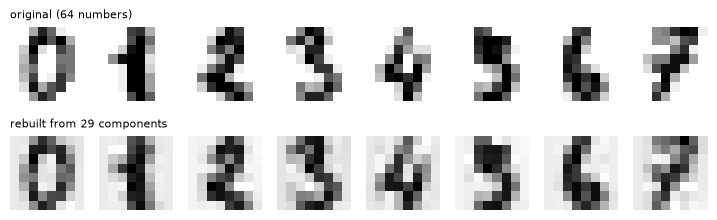

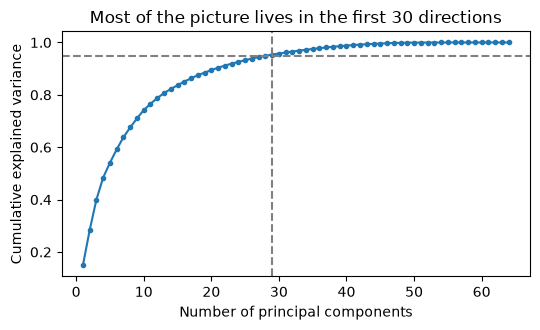

In [10]:
reconstructed = pca.inverse_transform(pca.transform(X_test.head(8)))

fig, axes = plt.subplots(2, 8, figsize=(9, 2.6))
for j in range(8):
    axes[0, j].imshow(X_test.iloc[j].to_numpy().reshape(8, 8), cmap="gray_r")
    axes[1, j].imshow(reconstructed[j].reshape(8, 8), cmap="gray_r")
    axes[0, j].axis("off")
    axes[1, j].axis("off")
axes[0, 0].set_title("original (64 numbers)", fontsize=8, loc="left")
axes[1, 0].set_title(f"rebuilt from {pca.n_components_} components", fontsize=8, loc="left")
plt.savefig(RESULTS / f"rebuilt_from_{pca.n_components_}_components.png", dpi=160, bbox_inches="tight")
plt.show()

plt.figure(figsize=(5.5, 3.4))
all_components = PCA(svd_solver="full").fit(X_dev)
plt.plot(np.arange(1, 65), np.cumsum(all_components.explained_variance_ratio_), marker=".")
plt.axhline(0.95, linestyle="--", color="grey")
plt.axvline(pca.n_components_, linestyle="--", color="grey")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("Most of the picture lives in the first 30 directions")
plt.tight_layout()
plt.savefig(RESULTS / "most_of_the_picture_lives_in_the_first_30_directions.png", dpi=160, bbox_inches="tight")
plt.show()

**What to look for.** The rebuilt digits are slightly blurred but unmistakable: what was thrown away was mostly pixel noise, which is why the classifier lost nothing. The curve climbs steeply and then flattens; the last 35 components together add under 5% of the variance.

The saved file carries the PCA and the classifier together, so a new 64-pixel image goes in and a digit comes out.

In [11]:
model_path = MODELS / "digits_pca_logistic.joblib"
joblib.dump(final_model, model_path)

loaded = joblib.load(model_path)
first_digits = X_test.iloc[:5]
print("predicted:", loaded.predict(first_digits).tolist())
print("actual:   ", y_test.iloc[:5].tolist())

predicted: [0, 1, 1, 3, 4]
actual:    [0, 1, 2, 3, 4]


**What the output shows.** All 64 pixels: validation accuracy 0.955. Keeping 95% of the variance needs 29 components (a 55% reduction) and scores 0.954. On the official test file both models score 0.9477, so the compression cost nothing, and the rebuilt digits show why: slightly blurred but unmistakable. Lab 7 comes back to this test file with a neural network.

## Evidence

Write the numbers above to the results folder. These files are regenerated on every run; do not edit them by hand.

In [12]:
pd.DataFrame({"k": ks, "inertia": inertias, "silhouette": silhouettes}).round(4).to_csv(
    RESULTS / "kmeans_diagnostics.csv", index=False)
segments.groupby("kmeans_cluster")[features].mean().round(1).to_csv(RESULTS / "cluster_profiles.csv")
pd.DataFrame({"component": np.arange(1, pca.n_components_ + 1),
              "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)}).round(4).to_csv(
    RESULTS / "pca_budget.csv", index=False)
pd.DataFrame([{"dataset": "optdigits (official test)", "model": "logistic, 64 pixels",
               "test_accuracy": accuracy_score(y_test, full_model.predict(X_test))},
              {"dataset": "optdigits (official test)", "model": f"PCA({pca.n_components_}) -> logistic",
               "test_accuracy": accuracy_score(y_test, final_model.predict(X_test))}]).round(4).to_csv(
    RESULTS / "metrics.csv", index=False)
print("Saved:", sorted(p.name for p in RESULTS.iterdir()))

Saved: ['cluster_profiles.csv', 'figure_02.png', 'kmeans_diagnostics.csv', 'metrics.csv', 'most_of_the_picture_lives_in_the_first_30_directions.png', 'pca_budget.csv', 'rebuilt_from_29_components.png', 'silhouette_look_for_the_peak.png', 'the_first_ten_training_digits_8_x_8_pixels_each.png']


## Try it yourself

Run DBSCAN again with `eps=0.5`. Count the clusters and the noise points, and decide which of the two DBSCAN results is more useful to a marketing team, and why.

Attempt it in the cell below before reading the solution.

In [13]:
# Your work here


### One solution

DBSCAN with a smaller radius, side by side with the lab's setting.

eps=0.75: clusters = 1  noise = 14
eps=0.50: clusters = 5  noise = 66  silhouette (clustered only) = 0.528


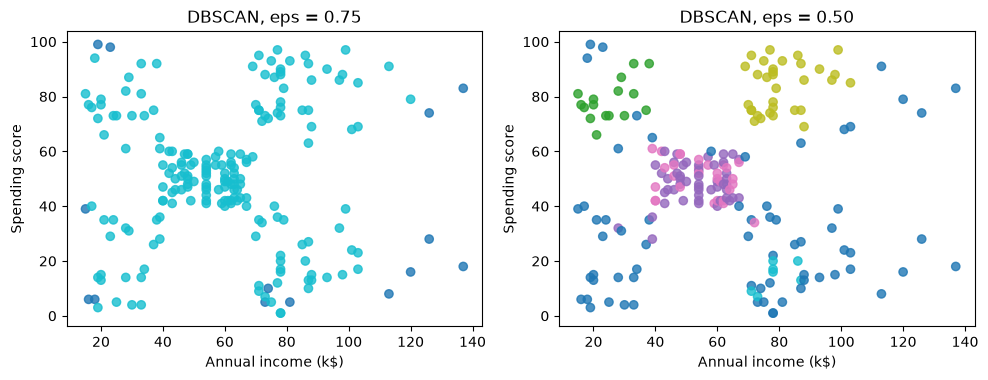

In [14]:
d_labels_small = DBSCAN(eps=0.5, min_samples=6).fit_predict(X)
clustered = d_labels_small != -1
n_small = len(set(d_labels_small[clustered]))
print("eps=0.75: clusters =", n_clusters, " noise =", int((d_labels == -1).sum()))
print("eps=0.50: clusters =", n_small, " noise =", int((~clustered).sum()),
      " silhouette (clustered only) =", round(silhouette_score(X[clustered], d_labels_small[clustered]), 3))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.9))
for ax, labels, title in [(axes[0], d_labels, "eps = 0.75"), (axes[1], d_labels_small, "eps = 0.50")]:
    ax.scatter(customers["Annual Income (k$)"], customers["Spending Score (1-100)"], c=labels, cmap="tab10", alpha=0.8)
    ax.set_xlabel("Annual income (k$)")
    ax.set_ylabel("Spending score")
    ax.set_title(f"DBSCAN, {title}")
plt.tight_layout()
plt.savefig(RESULTS / "dbscan_eps_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

**Which is more useful?** With `eps = 0.5` DBSCAN finds five dense cores that line up with the K-means corners, and its silhouette on the clustered points (0.53) is higher than K-means achieved (0.42), but it labels 66 of 200 customers as noise. For a marketing team that is the less useful result: a segmentation that cannot place one customer in three is hard to act on, and the 'noise' customers are not outliers, they simply sit between the dense corners. The `eps = 0.75` run is honest about the same fact from the other side: there is one continuous population. The practical answer is to use the K-means segments for targeting and to keep DBSCAN's message in mind when presenting them: the boundaries are drawn for convenience, not discovered.